# W1-D2: Log Mining + Parsing + Anomaly từ Log

Dataset chính: Loghub `BGL_2k.log` vì BGL có label anomaly ngay trong mỗi dòng log. Dataset phụ để test script: `HDFS_2k.log`.

Mục tiêu: parse log bằng Drain3, biến log text thành template, tạo template count time series, detect anomaly từ log, thử TF-IDF similarity giữa templates, inject log lạ, và build mini `log_analyzer.py`.

In [1]:
# Chạy cell này trước nếu môi trường chưa có thư viện.
%pip install -q drain3 pandas numpy matplotlib scikit-learn nbformat

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity

from log_analyzer import parse_logs

DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
OUTPUTS_DIR = Path('outputs')
RESULTS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

## Phase 1: Parse Log với Drain3

BGL log có format dạng: label, timestamp, node, component, level, rồi tới log content. Label `-` nghĩa là normal; label khác `-` nghĩa là anomaly. Em parse phần content bằng Drain3 để gom các dòng log giống nhau thành template.

In [3]:
raw_lines = (DATA_DIR / 'BGL_2k.log').read_text(encoding='utf-8', errors='ignore').splitlines()
label_counts = pd.Series([line.split()[0] for line in raw_lines]).value_counts()
print('Tổng số dòng BGL:', len(raw_lines))
print('Label distribution:')
print(label_counts.head(20))

Tổng số dòng BGL: 2000
Label distribution:
-           1857
KERNDTLB      60
KERNSTOR      30
APPSEV        17
KERNMNTF      11
KERNTERM       7
KERNREC        5
APPRES         4
APPREAD        3
KERNRTSP       2
APPTO          2
APPCHILD       1
APPOUT         1
Name: count, dtype: int64


### Drain3 tuning

Em thử `drain_sim_th = 0.3, 0.5, 0.7`. Threshold càng cao thì parser càng khó merge log line vào cùng template, nên số template có thể tăng mạnh. Em chọn `0.5` vì cân bằng: không merge quá rộng như 0.3, không tách quá vụn như 0.7.

In [4]:
tuning_rows = []
for sim_th in [0.3, 0.5, 0.7]:
    parsed_df, _ = parse_logs(DATA_DIR / 'BGL_2k.log', sim_th=sim_th)
    tuning_rows.append({
        'sim_th': sim_th,
        'unique_templates': parsed_df['template_id'].nunique(),
        'total_lines': len(parsed_df),
        'anomaly_lines': parsed_df['is_anomaly_label'].sum(),
    })

drain_tuning = pd.DataFrame(tuning_rows)
drain_tuning.to_csv(RESULTS_DIR / 'drain_tuning.csv', index=False)
drain_tuning

,sim_th,unique_templates,total_lines,anomaly_lines
0,0.3,100,2000,143
1,0.5,108,2000,143
2,0.7,919,2000,143


In [5]:
BEST_SIM_TH = 0.5
parsed_df, miner = parse_logs(DATA_DIR / 'BGL_2k.log', sim_th=BEST_SIM_TH)
parsed_df.to_csv(RESULTS_DIR / 'parsed_bgl.csv', index=False)

print('Total lines:', len(parsed_df))
print('Unique templates:', parsed_df['template_id'].nunique())
print('Anomaly lines:', parsed_df['is_anomaly_label'].sum())
parsed_df.head()

Total lines: 2000
Unique templates: 108
Anomaly lines: 143


,line_id,timestamp,label,is_anomaly_label,content,template_id,template,dataset
0,1,2005-06-03 15:42:50.675872,-,False,instruction cache parity error corrected,1,instruction cache parity error corrected,BGL
1,2,2005-06-03 15:42:53.276129,-,False,instruction cache parity error corrected,1,instruction cache parity error corrected,BGL
2,3,2005-06-03 15:49:36.156884,-,False,instruction cache parity error corrected,1,instruction cache parity error corrected,BGL
3,4,2005-06-03 15:49:38.026704,-,False,instruction cache parity error corrected,1,instruction cache parity error corrected,BGL
4,5,2005-06-03 16:47:20.730545,-,False,63543 double-hummer alignment exceptions,2,63543 double-hummer alignment exceptions,BGL


In [6]:
top_templates = (
    parsed_df.groupby(['template_id', 'template'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
top_templates.head(10).to_csv(RESULTS_DIR / 'top_templates.csv', index=False)
top_templates.head(10)

,template_id,template,count
7,5,generating <*>,720
104,71,iar <*> dear <*>,207
2,2,<*> double-hummer alignment exceptions,108
4,3,CE sym <*> at <*> mask <*>,91
78,56,<*> floating point alignment exceptions,84
143,95,<*> total interrupts. 0 critical input interru...,70
17,10,data TLB error interrupt,60
141,94,0 microseconds spent in the rbs signal handler...,51
0,1,instruction cache parity error corrected,42
77,56,8 floating point alignment exceptions,37


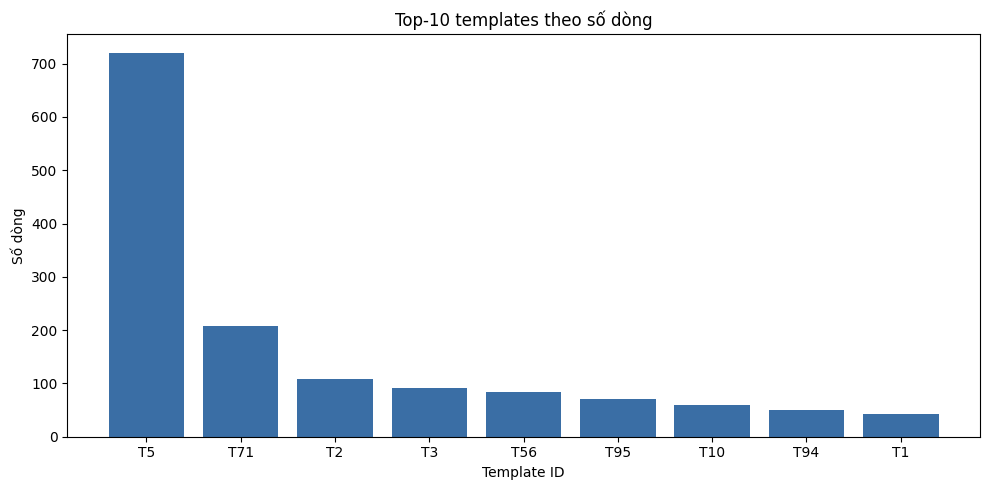

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
top10 = top_templates.head(10).copy()
top10['template_name'] = top10['template_id'].map(lambda x: f'T{x}')
ax.bar(top10['template_name'], top10['count'], color='#3a6ea5')
ax.set_title('Top-10 templates theo số dòng')
ax.set_xlabel('Template ID')
ax.set_ylabel('Số dòng')
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / '01_top_templates.png', dpi=160)
plt.show()

## Phase 2: Anomaly Detection trên Log

Em tạo template count time series theo window 5 phút. Ý tưởng: nếu một template tăng đột biến trong một window, đó có thể là signal anomaly. Ngoài detector z-score theo từng template, em thử thêm Isolation Forest trên vector template-count của từng window.

In [8]:
work = parsed_df.dropna(subset=['timestamp']).copy()
work['window'] = work['timestamp'].dt.floor('5min')

total_ts = work.groupby('window').size().rename('total_logs').reset_index()
label_ts = work.groupby('window')['is_anomaly_label'].max().rename('has_anomaly_label').reset_index()
total_ts = total_ts.merge(label_ts, on='window', how='left')

print('Số window 5 phút:', len(total_ts))
print('Window có anomaly label:', int(total_ts['has_anomaly_label'].sum()))
total_ts.head()

Số window 5 phút: 831
Window có anomaly label: 95


,window,total_logs,has_anomaly_label
0,2005-06-03 15:40:00,2,False
1,2005-06-03 15:45:00,2,False
2,2005-06-03 16:45:00,1,False
3,2005-06-03 16:55:00,2,False
4,2005-06-03 18:20:00,1,False


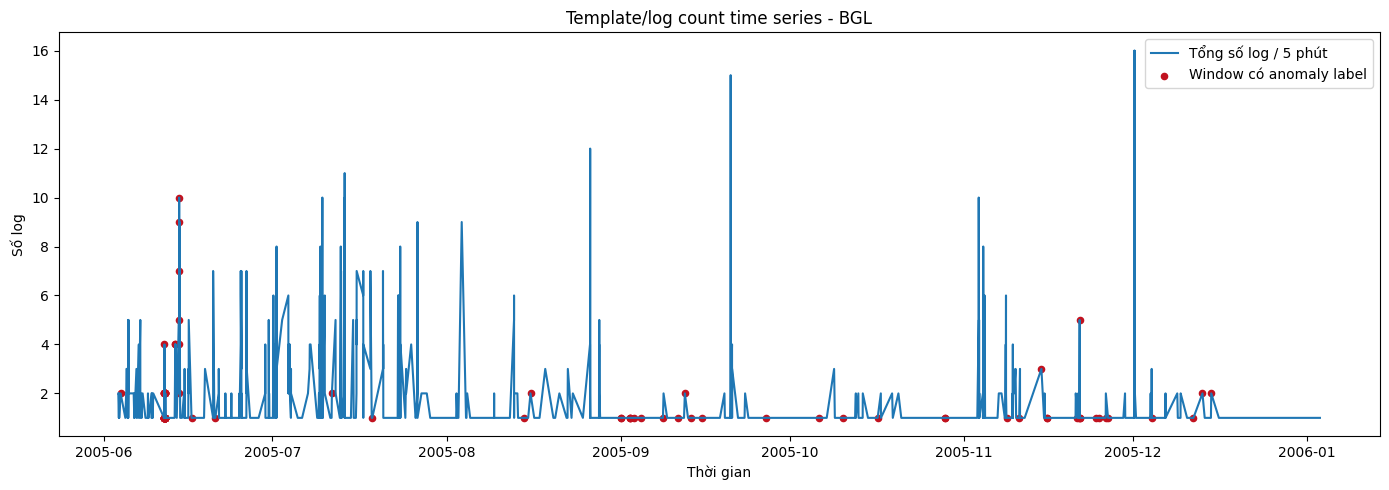

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(total_ts['window'], total_ts['total_logs'], label='Tổng số log / 5 phút')
anom = total_ts[total_ts['has_anomaly_label']]
ax.scatter(anom['window'], anom['total_logs'], color='#c1121f', s=20, label='Window có anomaly label')
ax.set_title('Template/log count time series - BGL')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số log')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / '02_template_count_timeseries.png', dpi=160)
plt.show()

In [10]:
counts = work.groupby(['template_id', 'template', 'window']).size().rename('count').reset_index()
stats = counts.groupby('template_id')['count'].agg(['mean', 'std']).reset_index()
counts = counts.merge(stats, on='template_id', how='left')
counts['std'] = counts['std'].fillna(0)
counts['z_score'] = (counts['count'] - counts['mean']) / counts['std'].replace(0, 1e-9)
spikes = counts[counts['z_score'] >= 3.0].sort_values('z_score', ascending=False)
spikes.to_csv(RESULTS_DIR / 'template_spikes.csv', index=False)
spikes.head(10)

,template_id,template,window,count,mean,std,z_score
449,10,data TLB error interrupt,2005-06-11 19:30:00,4,1.363636,0.613450,4.297599
346,5,generating <*>,2005-07-13 20:35:00,11,3.162281,2.155820,3.635610
142,3,CE sym <*> at <*> mask <*>,2005-10-19 05:10:00,2,1.069767,0.256249,3.630192
137,3,CE sym <*> at <*> mask <*>,2005-10-08 21:35:00,2,1.069767,0.256249,3.630192
163,3,CE sym <*> at <*> mask <*>,2005-12-04 04:45:00,2,1.069767,0.256249,3.630192
152,3,CE sym <*> at <*> mask <*>,2005-11-10 04:05:00,2,1.069767,0.256249,3.630192
110,3,CE sym <*> at <*> mask <*>,2005-08-21 00:55:00,2,1.069767,0.256249,3.630192
84,3,CE sym <*> at <*> mask <*>,2005-06-06 08:05:00,2,1.069767,0.256249,3.630192
579,43,ciod: Error loading <*> invalid or missing pro...,2005-09-20 17:55:00,4,1.312500,0.793200,3.388173
16,1,instruction cache parity error corrected,2005-06-15 09:25:00,3,1.235294,0.553711,3.187055


In [11]:
spike_keys = set(zip(spikes['template_id'], spikes['window']))
work['pred_spike'] = [(tid, win) in spike_keys for tid, win in zip(work['template_id'], work['window'])]

y_true_line = work['is_anomaly_label'].astype(int)
y_pred_line = work['pred_spike'].astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_line, y_pred_line, average='binary', zero_division=0)
tn, fp, fn, tp = confusion_matrix(y_true_line, y_pred_line, labels=[0, 1]).ravel()
spike_metrics = {'precision': precision, 'recall': recall, 'f1': f1, 'false_alarms': fp, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}
spike_metrics

{'precision': 0.04819277108433735,
 'recall': 0.027972027972027972,
 'f1': 0.035398230088495575,
 'false_alarms': np.int64(79),
 'tp': np.int64(4),
 'fp': np.int64(79),
 'fn': np.int64(139),
 'tn': np.int64(1778)}

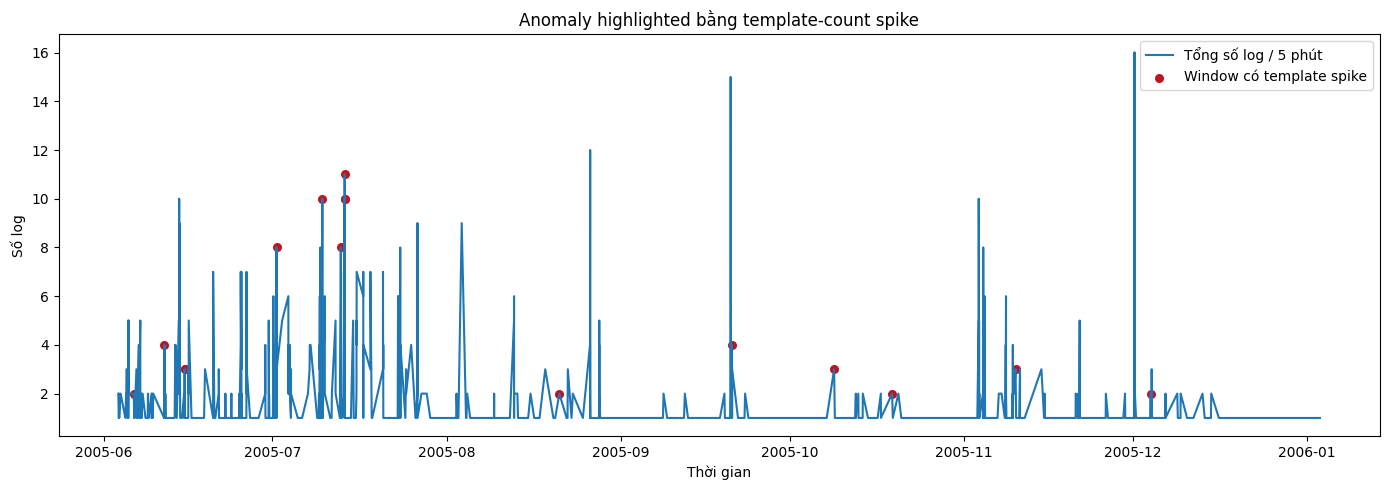

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(total_ts['window'], total_ts['total_logs'], label='Tổng số log / 5 phút')
spike_windows = sorted(set(spikes['window']))
spike_points = total_ts[total_ts['window'].isin(spike_windows)]
ax.scatter(spike_points['window'], spike_points['total_logs'], color='#c1121f', s=30, label='Window có template spike')
ax.set_title('Anomaly highlighted bằng template-count spike')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số log')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / '03_anomaly_highlighted.png', dpi=160)
plt.show()

### Isolation Forest trên template-count vector

Mỗi window 5 phút được biến thành một vector: mỗi feature là count của một template. Isolation Forest học window nào có pattern template-count khác thường.

In [13]:
template_matrix = work.pivot_table(index='window', columns='template_id', values='line_id', aggfunc='count', fill_value=0)
y_window = work.groupby('window')['is_anomaly_label'].max().loc[template_matrix.index].astype(int)

if_rows = []
best = None
for contamination in [0.01, 0.03, 0.05, 0.10, 0.20]:
    model = IsolationForest(n_estimators=300, contamination=contamination, random_state=42)
    pred = (model.fit_predict(template_matrix) == -1).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_window, pred, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_window, pred, labels=[0, 1]).ravel()
    row = {'contamination': contamination, 'precision': precision, 'recall': recall, 'f1': f1, 'false_alarms': fp, 'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}
    if_rows.append(row)
    if best is None or f1 > best['f1']:
        best = {**row, 'pred': pred}

if_tuning = pd.DataFrame(if_rows)
if_tuning.to_csv(RESULTS_DIR / 'if_window_tuning.csv', index=False)
if_tuning

,contamination,precision,recall,f1,false_alarms,tp,fp,fn,tn
0,0.01,0.222222,0.021053,0.038462,7,2,7,93,729
1,0.03,0.166667,0.042105,0.067227,20,4,20,91,716
2,0.05,0.121951,0.052632,0.073529,36,5,36,90,700
3,0.10,0.084337,0.073684,0.078652,76,7,76,88,660
4,0.20,0.170732,0.294737,0.216216,136,28,136,67,600


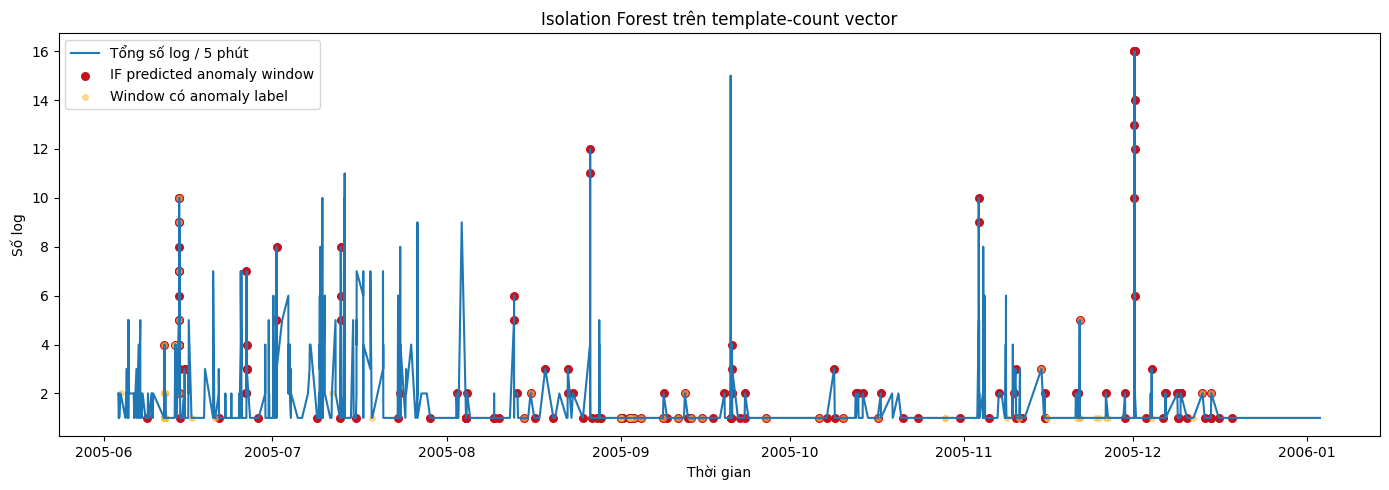

{'contamination': 0.2,
 'precision': 0.17073170731707318,
 'recall': 0.29473684210526313,
 'f1': 0.21621621621621623,
 'false_alarms': np.int64(136),
 'tp': np.int64(28),
 'fp': np.int64(136),
 'fn': np.int64(67),
 'tn': np.int64(600)}

In [14]:
if_points = total_ts.merge(pd.DataFrame({'window': template_matrix.index, 'pred_if': best['pred'], 'label': y_window.values}), on='window', how='left')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(if_points['window'], if_points['total_logs'], label='Tổng số log / 5 phút')
ax.scatter(if_points.loc[if_points['pred_if'] == 1, 'window'], if_points.loc[if_points['pred_if'] == 1, 'total_logs'], color='#c1121f', s=30, label='IF predicted anomaly window')
ax.scatter(if_points.loc[if_points['label'] == 1, 'window'], if_points.loc[if_points['label'] == 1, 'total_logs'], color='#fcbf49', s=16, alpha=0.55, label='Window có anomaly label')
ax.set_title('Isolation Forest trên template-count vector')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Số log')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / '04_if_template_count_anomaly.png', dpi=160)
plt.show()

best_if_metrics = {k: v for k, v in best.items() if k != 'pred'}
best_if_metrics

## Phase 3: Embedding + New Template Detection

TF-IDF giúp đo similarity giữa các template. Nếu nhiều template có cosine similarity cao, chúng có thể thuộc cùng một nhóm sự kiện. Ngoài ra, template mới xuất hiện là signal quan trọng vì nó cho thấy hệ thống sinh ra loại log chưa từng thấy.

In [15]:
templates = top_templates[['template_id', 'template']].copy().sort_values('template_id')
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b[^\s]+\b')
X = vectorizer.fit_transform(templates['template'])
sim = cosine_similarity(X)

pairs = []
ids = templates['template_id'].tolist()
texts = templates['template'].tolist()
for i in range(len(ids)):
    for j in range(i + 1, len(ids)):
        if sim[i, j] >= 0.45:
            pairs.append({'template_a': ids[i], 'template_b': ids[j], 'similarity': sim[i, j], 'text_a': texts[i], 'text_b': texts[j]})

similarity_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False).head(20)
similarity_df.to_csv(RESULTS_DIR / 'template_similarity_top.csv', index=False)
similarity_df.head(10)

,template_a,template_b,similarity,text_a,text_b
41,16,45,1.000000,program interrupt: <*> <*>,program interrupt
162,95,95,0.982544,10722 total interrupts. 0 critical input inter...,<*> total interrupts. 0 critical input interru...
23,9,9,0.971859,1 ddr errors(s) detected and corrected on rank...,1 ddr errors(s) detected and corrected on rank...
142,82,82,0.969329,"Error receiving packet on tree network, expect...","Error receiving packet on tree network, expect..."
97,66,66,0.969079,1 tree receiver 2 in re-synch state event(s) (...,<*> tree receiver 2 in re-synch state event(s)...
22,9,9,0.962830,1 ddr errors(s) detected and corrected on rank...,<*> ddr errors(s) detected and corrected on ra...
86,50,50,0.958320,1 torus receiver <*> input pipe error(s) (dcr ...,<*> torus receiver <*> input pipe error(s) (dc...
48,25,25,0.954771,floating pt ex mode <*> enable......0,floating pt ex mode 0 enable......0
107,68,68,0.946810,ciod: Error reading message prefix after LOAD_...,ciod: Error reading message prefix after LOAD_...
54,42,42,0.939378,total of 1 ddr error(s) detected and corrected,total of <*> ddr error(s) detected and corrected


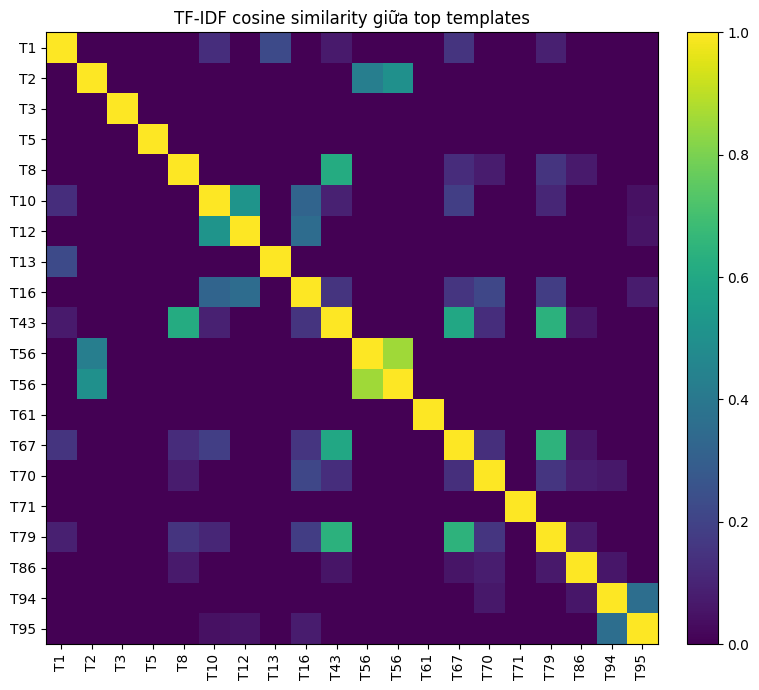

In [16]:
top20 = top_templates.head(20).sort_values('template_id')
X20 = vectorizer.fit_transform(top20['template'])
sim20 = cosine_similarity(X20)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim20, cmap='viridis', vmin=0, vmax=1)
labels = [f'T{int(x)}' for x in top20['template_id']]
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)
ax.set_title('TF-IDF cosine similarity giữa top templates')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / '05_template_similarity_heatmap.png', dpi=160)
plt.show()

In [17]:
weird_log = 'CRITICAL payment-service quantum cache exploded for tenant=abc retry_budget=-999 unusual_token=ZXCV_NOT_SEEN_BEFORE'
injected = miner.add_log_message(weird_log)
injected_result = {
    'change_type': injected['change_type'],
    'cluster_id': injected['cluster_id'],
    'template': injected['template_mined'],
}
Path(RESULTS_DIR / 'injected_new_template.json').write_text(json.dumps(injected_result, indent=2), encoding='utf-8')
injected_result

{'change_type': 'cluster_created',
 'cluster_id': 109,
 'template': 'CRITICAL payment-service quantum cache exploded for tenant=abc retry_budget=-999 unusual_token=ZXCV_NOT_SEEN_BEFORE'}

## Phase 4: Mini Log Analyzer

Script `log_analyzer.py` nhận input là một log file và in ra tổng số dòng, số template unique, top-5 template, template spike, và new templates trong giờ cuối. Em test script trên BGL và HDFS để so sánh.

In [18]:
for dataset in ['BGL_2k.log', 'HDFS_2k.log']:
    out_file = RESULTS_DIR / f"log_analyzer_{dataset.split('_')[0].lower()}.txt"
    with out_file.open('w', encoding='utf-8') as f:
        subprocess.run([sys.executable, 'log_analyzer.py', str(DATA_DIR / dataset)], stdout=f, check=True)

print((RESULTS_DIR / 'log_analyzer_bgl.txt').read_text(encoding='utf-8')[:1200])

Log file: data\BGL_2k.log
Total lines: 2000
Unique templates: 108
Detected dataset format: BGL

Top-5 templates:
- T5 | 720 lines | 36.00% | generating <*>
- T71 | 207 lines | 10.35% | iar <*> dear <*>
- T2 | 108 lines | 5.40% | <*> double-hummer alignment exceptions
- T3 | 91 lines | 4.55% | CE sym <*> at <*> mask <*>
- T56 | 84 lines | 4.20% | <*> floating point alignment exceptions

Template spikes in the last-hour style check (z >= 3.0):
- T5 | window=2005-07-09 21:00:00 | count=44 | z=4.13 | generating <*>
- T5 | window=2005-07-13 20:00:00 | count=39 | z=3.57 | generating <*>
- T1 | window=2005-06-15 09:00:00 | count=7 | z=3.12 | instruction cache parity error corrected
- T5 | window=2005-07-09 11:00:00 | count=35 | z=3.11 | generating <*>

New templates first seen in the final hour:
- No new templates in the final hour.



In [19]:
print((RESULTS_DIR / 'log_analyzer_hdfs.txt').read_text(encoding='utf-8')[:1200])

Log file: data\HDFS_2k.log
Total lines: 2000
Unique templates: 17
Detected dataset format: HDFS

Top-5 templates:
- T1 | 310 lines | 15.50% | PacketResponder <*> for block <*> terminating
- T2 | 300 lines | 15.00% | BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
- T4 | 291 lines | 14.55% | Receiving block <*> src: <*> dest: <*>
- T3 | 280 lines | 14.00% | Received block <*> of size <*> from <*>
- T7 | 262 lines | 13.10% | Deleting block <*> file <*>

Template spikes in the last-hour style check (z >= 3.0):
- T6 | window=2008-11-10 08:00:00 | count=3 | z=3.45 | Verification succeeded for <*>
- T8 | window=2008-11-10 08:00:00 | count=13 | z=3.45 | <*> Served block <*> to <*>

New templates first seen in the final hour:
- No new templates in the final hour.



## Bonus: Parse Docker logs LLM4Reqs

Em có kiểm tra Docker logs của project LLM4Reqs và export log từ 5 container: frontend, backend, llm, queue, reverb. Các log này được parse bằng cùng `log_analyzer.py`; parser cũng được bổ sung nhánh đọc timestamp ISO của Docker logs để có thể dùng các kiểm tra theo time window.


In [20]:
docker_log_files = {
    'frontend': DATA_DIR / 'docker_llm4reqs_frontend.log',
    'backend': DATA_DIR / 'docker_llm4reqs_backend.log',
    'llm': DATA_DIR / 'docker_llm4reqs_llm.log',
    'queue': DATA_DIR / 'docker_llm4reqs_queue.log',
    'reverb': DATA_DIR / 'docker_llm4reqs_reverb.log',
}

for service, logfile in docker_log_files.items():
    out_file = RESULTS_DIR / f'log_analyzer_llm4reqs_{service}.txt'
    with out_file.open('w', encoding='utf-8') as f:
        subprocess.run([sys.executable, 'log_analyzer.py', str(logfile)], stdout=f, check=True)

print((RESULTS_DIR / 'log_analyzer_llm4reqs_frontend.txt').read_text(encoding='utf-8')[:1600])


Log file: data\docker_llm4reqs_frontend.log
Total lines: 882
Unique templates: 20
Detected dataset format: Docker

Top-5 templates:
- T15 | 811 lines | 91.95% | 172.19.0.1 - - <*> +0000] <*> <*> HTTP/1.1" <*> <*> <*> "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/145.0.7632.6 Safari/537.36" "-"
- T18 | 10 lines | 1.13% | 2026/04/12 07:02:06 [notice] <*> <*>
- T13 | 7 lines | 0.79% | 2026/04/12 04:49:59 [notice] 1#1: start worker process <*>
- T15 | 7 lines | 0.79% | 172.19.0.1 - - [12/Apr/2026:04:52:15 +0000] "GET <*> HTTP/1.1" 200 <*> <*> "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/145.0.7632.6 Safari/537.36" "-"
- T19 | 7 lines | 0.79% | 2026/04/12 07:02:06 [notice] 1#1: worker process <*> exited with code 0

Template spikes in the last-hour style check (z >= 3.0):
- No strong template-count spikes found.

New templates first seen in the final hour:
- T16 | first_seen=2026-04-12 07:

In [21]:
bonus_rows = []
for service, logfile in docker_log_files.items():
    docker_df, _ = parse_logs(logfile, sim_th=BEST_SIM_TH)
    template_counts = docker_df.groupby(['template_id', 'template']).size().reset_index(name='count')
    top_template = template_counts.sort_values('count', ascending=False).iloc[0]
    bonus_rows.append({
        'service': service,
        'lines': len(docker_df),
        'unique_templates': docker_df['template_id'].nunique(),
        'top_template_percent': round(top_template['count'] / len(docker_df) * 100, 2),
        'top_template': top_template['template'],
    })

bonus_summary = pd.DataFrame(bonus_rows).sort_values('lines', ascending=False)
bonus_summary.to_csv(RESULTS_DIR / 'docker_llm4reqs_summary.csv', index=False)
bonus_summary


,service,lines,unique_templates,top_template_percent,top_template
0,frontend,882,20,91.95,"172.19.0.1 - - <*> +0000] <*> <*> HTTP/1.1"" <*..."
1,backend,478,5,97.70,"127.0.0.1 - <*> +0000 <*> /index.php"" <*>"
2,llm,318,25,74.84,"INFO: <*> - <*> <*> HTTP/1.1"" 200 OK"
3,queue,4,2,25.00,2026-04-12 05:04:05 App\Jobs\StreamMessageJob ...
4,reverb,3,2,66.67,


Nhận xét bonus: log thật có pattern lặp rất rõ, ví dụ access log và health check chiếm tỷ lệ lớn. Drain3 hữu ích ở đây vì nó gom các dòng khác IP, path, port, status hoặc timestamp thành template chung. Tuy nhiên log thật cũng cho thấy cần feature engineering trước khi detect anomaly: nên tách service, HTTP method/status/path, loại bỏ health check nếu quá áp đảo, rồi mới dùng template-count hoặc Isolation Forest để tránh false alarm.


## Reflection

Drain3 parse BGL ở mức chấp nhận được: với `sim_th=0.5`, parser tạo 108 templates từ 2000 dòng log. `sim_th=0.3` merge mạnh hơn nên chỉ có 100 templates; `sim_th=0.7` tách quá vụn, tạo tới 919 templates. Vì vậy em chọn 0.5.

Template có insight nhất là các template xuất hiện nhiều như `generating <*>`, `iar <*> dear <*>`, và các template liên quan alignment/cache/parity. Chúng cho biết log không chỉ là text rời rạc; sau khi parse, ta có thể đếm và theo dõi pattern theo thời gian.

Template-count spike detector có precision/recall thấp trên BGL 2k vì không phải anomaly nào cũng biểu hiện bằng volume spike. Isolation Forest trên template-count vector có F1 tốt hơn, nhưng vẫn có false alarm cao. Điều này phản ánh thực tế: log anomaly detection cần kết hợp nhiều signal hơn như template mới, severity, service/component, và metric anomaly.

Metric cho biết hệ thống đang bất thường ở đâu, ví dụ latency tăng hoặc error rate tăng. Log giúp giải thích vì sao, ví dụ timeout DB, circuit breaker open, hoặc kernel error. Kết hợp metric + log giúp vừa detect incident vừa triage/root-cause nhanh hơn.

## Tóm tắt kết quả

| Hạng mục | Kết quả |
|---|---:|
| Dataset chính | BGL_2k.log |
| Dataset test script | HDFS_2k.log |
| Tổng dòng BGL | 2000 |
| Anomaly lines BGL | 143 |
| Drain sim_th chọn | 0.5 |
| Unique templates | 108 |
| Template-count spike F1 | 0.035 |
| Best IF contamination | 0.20 |
| Best IF F1 | 0.216 |

| Drain sim_th | Unique templates | Nhận xét |
|---:|---:|---|
| 0.3 | 100 | Merge mạnh hơn |
| 0.5 | 108 | Cân bằng nhất |
| 0.7 | 919 | Tách quá vụn |